In [3]:
import numpy as np
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore', category=RuntimeWarning)

# Definiendo las funciones:

1. $$f_1(x) = 1 - e^{-x} + \frac{1}{1+x}, x\in [0, 20]$$
2. $$f_2(x) = \frac{x+2.5}{4-x²}, x \in [-1.9, 1.9]$$
3. $$f_3(x) = -2\sin{x} + \sin{2x} - 2\sin(3x), x\in [1, 3]$$

# Clase de Optimización con algoritmos en métodos:

In [4]:
class OptimizacionUnivariada:
    
    @staticmethod
    def seccion_dorada(f, xl, xu, tol=1e-8, tipo='min'):
        """Encuentra el óptimo de una función usando la Búsqueda de la Sección Dorada."""
        phi = (np.sqrt(5) - 1) / 2
        
        # Si buscamos máximo, invertimos la función (Min del inverso).
        func = f if tipo == 'min' else lambda x: -f(x)
        
        d = phi * (xu - xl)
        x1 = xl + d
        x2 = xu - d
        
        f1 = func(x1)
        f2 = func(x2)
        
        iteracion = 0
        while (xu - xl) > tol:
            if f1 < f2:
                xl = x2
                x2 = x1
                f2 = f1
                d = phi * (xu - xl)
                x1 = xl + d
                f1 = func(x1)
            else:
                xu = x1
                x1 = x2
                f1 = f2
                d = phi * (xu - xl)
                x2 = xu - d
                f2 = func(x2)
            iteracion += 1
            
        x_opt = (xl + xu) / 2
        return x_opt, iteracion

    @staticmethod
    def interpolacion_parabolica(f, x0, x1, x2, tol=1e-8, max_iter=1000, tipo='min'):
        """Encuentra el óptimo de una función mediante Interpolación Parabólica Sucesiva."""
        func = f if tipo == 'min' else lambda x: -f(x)
        
        x_old = x1
        for iteracion in range(max_iter):
            f0, f1_val, f2 = func(x0), func(x1), func(x2)
            
            numerador = (x1 - x0)**2 * (f1_val - f2) - (x1 - x2)**2 * (f1_val - f0)
            denominador = 2 * ((x1 - x0) * (f1_val - f2) - (x1 - x2) * (f1_val - f0))
            
            if denominador == 0:
                raise ValueError("División por cero en la interpolación parabólica.")
                
            x3 = x1 - numerador / denominador
            
            if abs(x3 - x_old) < tol:
                return x3, iteracion + 1
                
            # Actualización de puntos (nos movemos de punto, vaya)
            x0, x1, x2 = x1, x3, x2
            x_old = x3
            
        raise ValueError("Interpolación parabólica no convergió.")

    @staticmethod
    def newton_raphson_opt(fp, fpp, x0, tol=1e-8, max_iter=1000):
        """Encuentra el óptimo buscando las raíces de f'(x) = 0 usando f''(x)."""
        x = x0
        for iteracion in range(max_iter):
            derivada1 = fp(x)
            derivada2 = fpp(x)
            
            if derivada2 == 0:
                raise ValueError("La segunda derivada es cero, el método falla.")
                
            x_new = x - derivada1 / derivada2
            
            if abs(x_new - x) < tol:
                return x_new, iteracion + 1
                
            x = x_new
            
        raise ValueError("Newton-Raphson no convergió.")

## Cálculo de Derivadas:

In [5]:
# Función 1
def f1(x):   return 1 - np.exp(-x) + 1/(1+x)
def f1_p(x): return np.exp(-x) - 1/((1+x)**2)
def f1_pp(x): return -np.exp(-x) + 2/((1+x)**3)

# Función 2
def f2(x):   return (x + 2.5) / (4 - x**2)
def f2_p(x): return (x**2 + 5*x + 4) / ((4 - x**2)**2)
def f2_pp(x): 
    # Derivada segunda obtenida por regla del cociente
    num = 2 * (x**3 + 7.5*x**2 + 12*x + 20)
    den = (4 - x**2)**3
    return num / den

# Función 3
def f3(x):   return -2*np.sin(x) + np.sin(2*x) - 2*np.sin(3*x)
def f3_p(x): return -2*np.cos(x) + 2*np.cos(2*x) - 6*np.cos(3*x)
def f3_pp(x): return 2*np.sin(x) - 4*np.sin(2*x) + 18*np.sin(3*x)

# Gráficas:


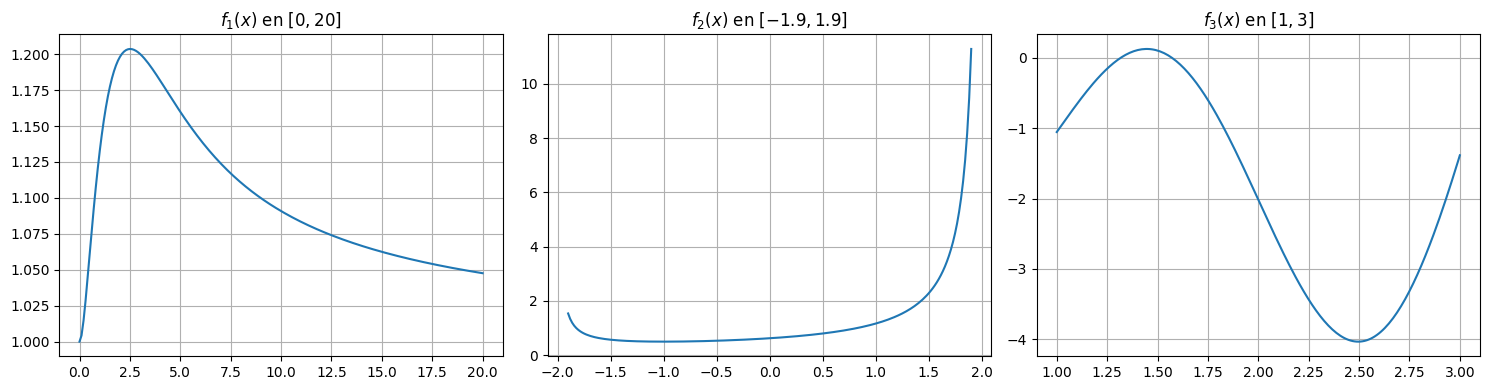

In [6]:
fig, axs = plt.subplots(1, 3, figsize=(15, 4))

x1_vals = np.linspace(0, 20, 200)
axs[0].plot(x1_vals, f1(x1_vals))
axs[0].set_title(r'$f_1(x)$ en $[0, 20]$')
axs[0].grid(True)

x2_vals = np.linspace(-1.9, 1.9, 200)
axs[1].plot(x2_vals, f2(x2_vals))
axs[1].set_title(r'$f_2(x)$ en $[-1.9, 1.9]$')
axs[1].grid(True)

x3_vals = np.linspace(1, 3, 200)
axs[2].plot(x3_vals, f3(x3_vals))
axs[2].set_title(r'$f_3(x)$ en $[1, 3]$')
axs[2].grid(True)

plt.tight_layout()
plt.show()

# Resultados:

In [11]:
optimizador = OptimizacionUnivariada()
tol = 1e-8

print("=== FUNCIÓN 1: Extremos locales en [0, 20] ===")

# 1. Búsqueda del Mínimo Local (Cercano a x=0 según la gráfica).
print("--- Buscando el Mínimo Local ---")
res_sd_1_min, it_sd_1_min = optimizador.seccion_dorada(f1, 0, 1, tol, tipo='min')
res_ip_1_min, it_ip_1_min = optimizador.interpolacion_parabolica(f1, 0.0, 0.1, 0.5, tol, tipo='min')
res_nr_1_min, it_nr_1_min = optimizador.newton_raphson_opt(f1_p, f1_pp, 0.1, tol)

print(f"Sección Dorada: x = {res_sd_1_min:.8f} (Iteraciones: {it_sd_1_min})")
print(f"Int. Parabólica: x = {res_ip_1_min:.8f} (Iteraciones: {it_ip_1_min})")
print(f"Newton-Raphson:  x = {res_nr_1_min:.8f} (Iteraciones: {it_nr_1_min})\n")

# 2. Búsqueda del Máximo Local (Cercano a x=2.5 aporximadamente).
print("--- Buscando el Máximo Local ---")
res_sd_1_max, it_sd_1_max = optimizador.seccion_dorada(f1, 1.5, 4.0, tol, tipo='max')
res_ip_1_max, it_ip_1_max = optimizador.interpolacion_parabolica(f1, 1.5, 2.5, 3.5, tol, tipo='max')
res_nr_1_max, it_nr_1_max = optimizador.newton_raphson_opt(f1_p, f1_pp, 2.5, tol)

print(f"Sección Dorada: x = {res_sd_1_max:.8f} (Iteraciones: {it_sd_1_max})")
print(f"Int. Parabólica: x = {res_ip_1_max:.8f} (Iteraciones: {it_ip_1_max})")
print(f"Newton-Raphson:  x = {res_nr_1_max:.8f} (Iteraciones: {it_nr_1_max})\n")


print("=== FUNCIÓN 2: Extremo local en [-1.9, 1.9] ===")
# f2 tiene un mínimo local cerca de x = -1
res_sd_2, it_sd_2 = optimizador.seccion_dorada(f2, -1.5, -0.5, tol, tipo='min')
res_ip_2, it_ip_2 = optimizador.interpolacion_parabolica(f2, -1.5, -1.0, -0.5, tol, tipo='min')
res_nr_2, it_nr_2 = optimizador.newton_raphson_opt(f2_p, f2_pp, -0.8, tol)

print(f"Sección Dorada: x = {res_sd_2:.8f} (Iteraciones: {it_sd_2})")
print(f"Int. Parabólica: x = {res_ip_2:.8f} (Iteraciones: {it_ip_2})")
print(f"Newton-Raphson:  x = {res_nr_2:.8f} (Iteraciones: {it_nr_2})\n")


print("=== FUNCIÓN 3: Extremos locales en [1, 3] ===")

# 1. Aislando un Mínimo Local (observando la gráfica, hay uno cerca de x=2.5)
print("--- Buscando un Mínimo Local ---")
res_sd_3_min, it_sd_3_min = optimizador.seccion_dorada(f3, 2.2, 2.8, tol, tipo='min')
res_ip_3_min, it_ip_3_min = optimizador.interpolacion_parabolica(f3, 2.3, 2.5, 2.7, tol, tipo='min')
res_nr_3_min, it_nr_3_min = optimizador.newton_raphson_opt(f3_p, f3_pp, 2.5, tol)

print(f"Sección Dorada: x = {res_sd_3_min:.8f} (Iteraciones: {it_sd_3_min})")
print(f"Int. Parabólica: x = {res_ip_3_min:.8f} (Iteraciones: {it_ip_3_min})")
print(f"Newton-Raphson:  x = {res_nr_3_min:.8f} (Iteraciones: {it_nr_3_min})\n")

# 2. Aislando un Máximo Local (observando la gráfica, hay uno cerca de x=1.4)
print("--- Buscando un Máximo Local ---")
res_sd_3_max, it_sd_3_max = optimizador.seccion_dorada(f3, 1.2, 1.6, tol, tipo='max')
res_ip_3_max, it_ip_3_max = optimizador.interpolacion_parabolica(f3, 1.2, 1.4, 1.6, tol, tipo='max')
res_nr_3_max, it_nr_3_max = optimizador.newton_raphson_opt(f3_p, f3_pp, 1.4, tol)

print(f"Sección Dorada: x = {res_sd_3_max:.8f} (Iteraciones: {it_sd_3_max})")
print(f"Int. Parabólica: x = {res_ip_3_max:.8f} (Iteraciones: {it_ip_3_max})")
print(f"Newton-Raphson:  x = {res_nr_3_max:.8f} (Iteraciones: {it_nr_3_max})")

=== FUNCIÓN 1: Extremos locales en [0, 20] ===
--- Buscando el Mínimo Local ---
Sección Dorada: x = 0.00000000 (Iteraciones: 39)
Int. Parabólica: x = -0.00000003 (Iteraciones: 47)
Newton-Raphson:  x = 0.00000000 (Iteraciones: 5)

--- Buscando el Máximo Local ---
Sección Dorada: x = 2.51286229 (Iteraciones: 41)
Int. Parabólica: x = 2.51286245 (Iteraciones: 25)
Newton-Raphson:  x = 2.51286242 (Iteraciones: 3)

=== FUNCIÓN 2: Extremo local en [-1.9, 1.9] ===
Sección Dorada: x = -1.00000001 (Iteraciones: 39)
Int. Parabólica: x = -1.00000001 (Iteraciones: 18)
Newton-Raphson:  x = -0.99999998 (Iteraciones: 43)

=== FUNCIÓN 3: Extremos locales en [1, 3] ===
--- Buscando un Mínimo Local ---
Sección Dorada: x = 2.49589688 (Iteraciones: 38)
Int. Parabólica: x = 2.49589687 (Iteraciones: 7)
Newton-Raphson:  x = 2.49589688 (Iteraciones: 3)

--- Buscando un Máximo Local ---
Sección Dorada: x = 1.44646016 (Iteraciones: 37)
Int. Parabólica: x = 1.44646016 (Iteraciones: 8)
Newton-Raphson:  x = 1.446460